# Reproducible Code for: Neutral mutations promote unbounded adaptation after clonal interference.

### Salvador León Fernández, Miguel Ángel Fortuna Alcolado.

We are going to reproduce the figures and statistical analyses from the Results and Discussion section: **Beneficial exhaustion drives a shift toward neutral evolution**.

---

## Setup & Environment

In [2]:
library("tidyverse")
library("scales") 
library("patchwork")
library("data.table")

## Data Loading

#### Read mutations fixed by selection:

In [4]:
db_fixed <- read_csv("../../DATA/db_fixed_mutations.csv") %>% mutate(rep_id_paired = ifelse(mut_rate == 0.01, rep_id - 200, rep_id))
db_fixed %>% head(3)
db_fixed %>% tail(3)

Rows: 26735 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): resource, mut_type, sequence
dbl (8): rep_id, founder_id, env_id, phenotype_id, mut_rate, update, fitness...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,1012,1659,1,NOT,0.001,NA,0,0.0731707,0.00000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1,1012,1659,1,NOT,0.001,sub,1911,0.0731707,1.00000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1,1012,1659,1,NOT,0.001,sub,8688,0.0757576,1.03535,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
499,1108,569,1,NOT,1e-04,sub,144034,0.0566038,1.93396,unmucybqueqywzjbzqcaobevwrchcovsqzvyptscuahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499
499,1108,569,1,NOT,1e-04,ins,149452,0.0757576,1.33838,unmucybqueqywzjbzqcaobevwrchcovsqzvvyptscuahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499
499,1108,569,1,NOT,1e-04,sub,496549,0.0821918,1.08493,unmucybqueqywzjbzqcaobevwrchcovsqzvvyptsceahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499


#### Read lineages fixed by selection from files:

In [5]:
db_lineages <- read_csv("DATA/db_lineages.csv") %>% mutate(rep_id = ifelse(mut_rate == 0.01, rep_id - 200, rep_id))
    db_lineages %>% nrow
    db_lineages %>% head(3)
    db_lineages %>% tail(3)

Rows: 473705 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): mut_type, sequence
dbl (11): ancestor_dist, gest_time, length, exe_length, mut_rate, founder_id...
lgl  (1): is_main_lineage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 473705

ancestor_dist,gest_time,length,exe_length,mut_rate,founder_id,rep_id,update,lineage_id,is_main_lineage,fitness,relative_fitness,mut_type,sequence
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<chr>,<chr>
0,410,100,71,0.01,1012,41,-1,4,TRUE,0.0731707,0.00000,ancestor,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx
1,396,100,58,0.01,1012,41,238,4,TRUE,0.0757576,1.03535,sub,qmwuukrmwxqyqruiytjaalgcirofzhipuhxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx
2,317,101,59,0.01,1012,41,5469,4,TRUE,0.0946372,1.24921,ins,qmwuukrmwxqyqruiytjaalgcirofzhipuhxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixvgjudyjaodjfhx


ancestor_dist,gest_time,length,exe_length,mut_rate,founder_id,rep_id,update,lineage_id,is_main_lineage,fitness,relative_fitness,mut_type,sequence
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<chr>,<chr>
13,1183,103,52,0.001,1439,28,499991,22,FALSE,0.0253593,0.305156,sub,osrwulmoljagcjbmytazncqppthbrklzxdecvvnrcuvybibivhwwhyerbgusrqjodneudkazscnbppudgxdencnkhdsjblkeyvgganl
13,361,103,52,0.001,1439,28,493893,23,FALSE,0.0831025,1.000000,sub,osrwulmoljagcjbmytazncqppthbrklzxdecvvnrcuvybrbivhwwhyerbgusrqjodneudkazscnbppudgxdxncnkhdsjblkeyvgganl
13,361,103,52,0.001,1439,28,499932,24,FALSE,0.0831025,1.000000,sub,osrwulmojjagcjbmytazncqppthbrklzxdecvvnrcuvybrbivhwwhyerbgusrqjodneudkazscnbppudgxdencnkhdsjblkeyvgganl


In [6]:
db_lineages_unique <- db_lineages %>%
    group_by(rep_id, mut_rate, lineage_id) %>%
    filter(update != max(update)) %>%
    ungroup() %>%
    group_by(rep_id, mut_rate, sequence) %>%
    slice_min(update, with_ties = FALSE) %>%
    ungroup() %>%
    arrange(rep_id, mut_rate, update) %>%
    select(-lineage_id, -ancestor_dist)
db_lineages_unique %>% head(5)

gest_time,length,exe_length,mut_rate,founder_id,rep_id,update,is_main_lineage,fitness,relative_fitness,mut_type,sequence
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<chr>,<chr>
410,100,71,0.001,1012,1,-1,TRUE,0.0731707,0.00000,ancestor,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx
410,100,71,0.001,1012,1,1911,TRUE,0.0731707,1.00000,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx
396,100,58,0.001,1012,1,8688,TRUE,0.0757576,1.03535,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx
346,100,58,0.001,1012,1,25860,TRUE,0.0867052,1.14451,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviaxgjudyjaodjfhx
283,101,59,0.001,1012,1,38954,TRUE,0.1060070,1.22261,ins,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviaxvgjudyjaodjfhx


#### Read muutants alive every 1000 updates:

In [7]:
db_load_lineages <- fread("../../DATA/db_mut_load.csv", 
                 colClasses = c("integer", "integer", "character", "numeric", 
                                "integer", "integer", "character", "integer")) %>%
    filter(mu > 0.0005) %>%
    mutate(rep_id = ifelse(rep_id > 200, rep_id - 200, rep_id)) %>%
    arrange(rep_id, update)
    
db_load_lineages %>% head
db_load_lineages %>% tail

founder_id,env_id,resource,mu,rep_id,update,sequence,abundance
<int>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>
1012,1659,NOT,0.001,1,0,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1012,1659,NOT,0.010,1,0,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1012,1659,NOT,0.001,1,1000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9926
1012,1659,NOT,0.001,1,1000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjusazvuviixgjudyjaodjfhx,18
1012,1659,NOT,0.001,1,1000,qmwuukrmwxqyqruxytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,12
1012,1659,NOT,0.001,1,1000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpgpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9


founder_id,env_id,resource,mu,rep_id,update,sequence,abundance
<int>,<int>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>
1317,1787,NOT,0.01,200,500000,dywkbfbfrcdaeqhcsjcecyczncxvuvevyvvgmbtloqlvwzfzkjorlyqsomfoyobgfbpkadkhohsfwhfnhlthnovlgeczjhxdiv,1
1317,1787,NOT,0.01,200,500000,dywkbfbfrcdaeqhcsjcecyczncxvuvevyvvgmgutloqlvwzfzkljorlyqsjmfoyobgfbpkadkhohsfwhfnhlthnovlgeczjhxdiv,1
1317,1787,NOT,0.01,200,500000,dywkbfbfrcdaeqhcsjcecyczncxvuvevyvvgmutloqlvwzfzkljorlyqsjmfoyobgfbpadkhohsfwhfnhlthnovlgeczjhxdiv,1
1317,1787,NOT,0.01,200,500000,dywkbfbfrcdaeqhcsjcecyczncxvuvevyvvgmutloqlvwzfzkljorlyqsomfoyobgfbpkadkhohsfwhfnhlthnovlgeczjhxiv,1
1317,1787,NOT,0.01,200,500000,dywkbfbfrcdaeqhcsjcecyzncxvuvevyvvgmstloqlvwzfzkljoxlyqsomfoyobgfbpkadkhohsfwhfnhlthnovlgeczjhxdiv,1
1317,1787,NOT,0.01,200,500000,lwkbfbfrcdaeqhcsjcecyczncxvuvevyvvgmutloglvwzfzrljorlyqsomfocobpfbpkaddhodsfwhfnhlthuovlgeczjhedbv,1


#### Read mutational supply data

In [3]:
# ==============================================================================
# DATA GENERATION PIPELINE (For Reproducibility Only)
# ==============================================================================
# The following block of code was used to process the massive raw dataset 
# ("DATA/db_mut_supply.csv") and generate the summary file used in this script. 
# It is commented out to save execution time and memory during standard runs, 
# as the final processed file is already provided in the repository.
#
# db_available <- fread("../../DATA/db_mut_supply.csv", colClasses = cls) %>%
#  filter(mut_rate > 0.0005) %>%
#  mutate(relative_fitness = ifelse(update == 0, NA, relative_fitness)) %>%
#  arrange(rep_id, update)
#
# db_available_summary <- db_available %>%
#  filter(
#    !is.na(relative_fitness), 
#    !is.na(mut_rate),
#    resource == "NOT",
#    update != 0                
#  ) %>%
#  mutate(
#    update_bin = ceiling(update / 1000) * 1000, 
#    effect_type = case_when(
#      relative_fitness > 1  ~ "Beneficial",
#      relative_fitness == 1 ~ "Neutral",
#      relative_fitness < 1 & relative_fitness > 0  ~ "Deleterious",
#      relative_fitness == 0  ~ "Lethal"
#    ),
#    effect_type = factor(effect_type, levels = c("Lethal", "Beneficial", "Neutral", "Deleterious")),
#    mut_rate    = factor(mut_rate)
#  ) %>%
#  count(mut_rate, update_bin, effect_type) %>%
#  group_by(mut_rate, update_bin) %>%
#  mutate(percentage = (n / sum(n)) * 100) %>%
#  ungroup()
#
# write_csv(db_available_summary, file = "../../DATA/db_mut_supply_summary.csv")
# ==============================================================================

db_available_summary = read_csv(file = "../../DATA/db_mut_supply_summary.csv")
db_available_summary %>% head
db_available_summary %>% tail

Rows: 4000 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): effect_type
dbl (4): mut_rate, update_bin, n, percentage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


mut_rate,update_bin,effect_type,n,percentage
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
0.001,1000,Lethal,11177,47.43856
0.001,1000,Beneficial,3180,13.49688
0.001,1000,Neutral,5156,21.88362
0.001,1000,Deleterious,4048,17.18093
0.001,2000,Lethal,14516,41.36202
0.001,2000,Beneficial,4681,13.33808


mut_rate,update_bin,effect_type,n,percentage
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
0.01,499000,Neutral,216502,23.15692872
0.01,499000,Deleterious,232656,24.88475122
0.01,500000,Lethal,485377,51.70174329
0.01,500000,Beneficial,639,0.06806547
0.01,500000,Neutral,218020,23.22321427
0.01,500000,Deleterious,234766,25.00697698


---

## Statistical Analysis Function:

In [11]:
perform_paired_analysis <- function(data, rep_col, cond_col, val_col, group1, group2) {
  
  # Pivot data to align paired observations
  df_paired <- data %>%
    select(all_of(c(rep_col, cond_col, val_col))) %>%
    pivot_wider(names_from = all_of(cond_col), values_from = all_of(val_col)) %>%
    drop_na() # Drop incomplete pairs
  
  vec_g1 <- df_paired[[group1]]
  vec_g2 <- df_paired[[group2]]
  
  differences <- vec_g1 - vec_g2
  
  # Check normality of differences
  shapiro_res <- shapiro.test(differences)
  
  cat("\n--------------------------------------------------\n")
  cat("1. NORMALITY TEST RESULTS (Shapiro-Wilk)\n")
  cat("--------------------------------------------------\n")
  cat("P-value:", round(shapiro_res$p.value, 5), "\n\n")
  
  # Select and run the appropriate test
  if (shapiro_res$p.value > 0.05) {
    
    cat("=> Differences FOLLOW a normal distribution (p > 0.05).\n")
    cat("=> Running Paired T-Test (Parametric)...\n\n")
    
    stat_test_res <- t.test(vec_g1, vec_g2, paired = TRUE)
    
  } else {
    
    cat("=> Differences DO NOT follow a normal distribution (p < 0.05).\n")
    cat("=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...\n\n")
    
    # Handle zero-difference ties smoothly
    stat_test_res <- wilcox.test(vec_g1, vec_g2, paired = TRUE, exact = FALSE) 
  }
  
  cat("--------------------------------------------------\n")
  cat("2. STATISTICAL TEST RESULTS\n")
  cat("--------------------------------------------------\n")
  print(stat_test_res)
  
  # Plot the distribution of differences
  p_diff <- ggplot(data.frame(diff = differences), aes(x = diff)) +
    geom_density(fill = "gray80", alpha = 0.5, color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
    labs(title = "Distribution of Paired Differences",
         subtitle = paste("Selected test:", stat_test_res$method),
         x = paste("Difference (", group1, "-", group2, ")"),
         y = "Density") +
    theme_minimal()
  
  print(p_diff)
  
  # Return objects silently for optional assignment
  invisible(list(
    shapiro = shapiro_res,
    stat_test = stat_test_res,
    plot = p_diff
  ))
}

---

## Statistical Analysis & Figure Generation

In [12]:
# ==============================================================================
# FIGURE EXPORT TEMPLATE (Optional)
# ==============================================================================
# If you wish to extract and save any of the generated plots in high resolution,
# you can uncomment and use the following base template. 
# Just replace 'your_plot_variable' with the actual name of the plot object 
# you want to save (e.g., relative_fitness_ci, final_plot, etc.).

# dir.create("Figures", showWarnings = FALSE)

# ggsave(
#   filename = "Figures/your_figure_name.png", 
#   plot     = your_plot_variable, 
#   width    = 5, 
#   height   = 6, 
#   units    = "in", 
#   dpi      = 600, 
#   bg       = "white", 
#   scale    = 1.2
# )

### Figure 3A. Effects of fixed mutations over time

#### Relative frequency of fixed mutations over time

In [35]:
db_fixed_per100_NOT <- db_fixed %>%
  filter(
    !is.na(relative_fitness),
    mut_rate > 0.0005,
    !is.na(mut_rate),
    resource == "NOT",
    update != 0               
  ) %>%
  mutate(
    # Binning: Rounds updates up to the nearest 1000-step interval
    update_bin = ceiling(update / 1000) * 1000, 
    
    # Classification of mutational effects based on relative fitness
    effect_type = case_when(
      relative_fitness > 1  ~ "Beneficial",
      relative_fitness == 1 ~ "Neutral",
      relative_fitness < 1  ~ "Deleterious"
    ),
    
    # Define factor levels for consistent plotting order
    effect_type = factor(effect_type, levels = c("Beneficial", "Neutral", "Deleterious")),
    mut_rate    = factor(mut_rate)
  ) %>%
  
  # Calculate frequency and relative proportions (percentage)
  count(mut_rate, update_bin, effect_type) %>%
  group_by(mut_rate, update_bin) %>%
  mutate(percentage = (n / sum(n)) * 100) %>%
  ungroup()

db_fixed_per100_NOT %>% head()

mut_rate,update_bin,effect_type,n,percentage
<fct>,<dbl>,<fct>,<int>,<dbl>
0.001,1000,Beneficial,37,100.000000
0.001,2000,Beneficial,44,93.617021
0.001,2000,Neutral,2,4.255319
0.001,2000,Deleterious,1,2.127660
0.001,3000,Beneficial,55,94.827586
0.001,3000,Neutral,1,1.724138


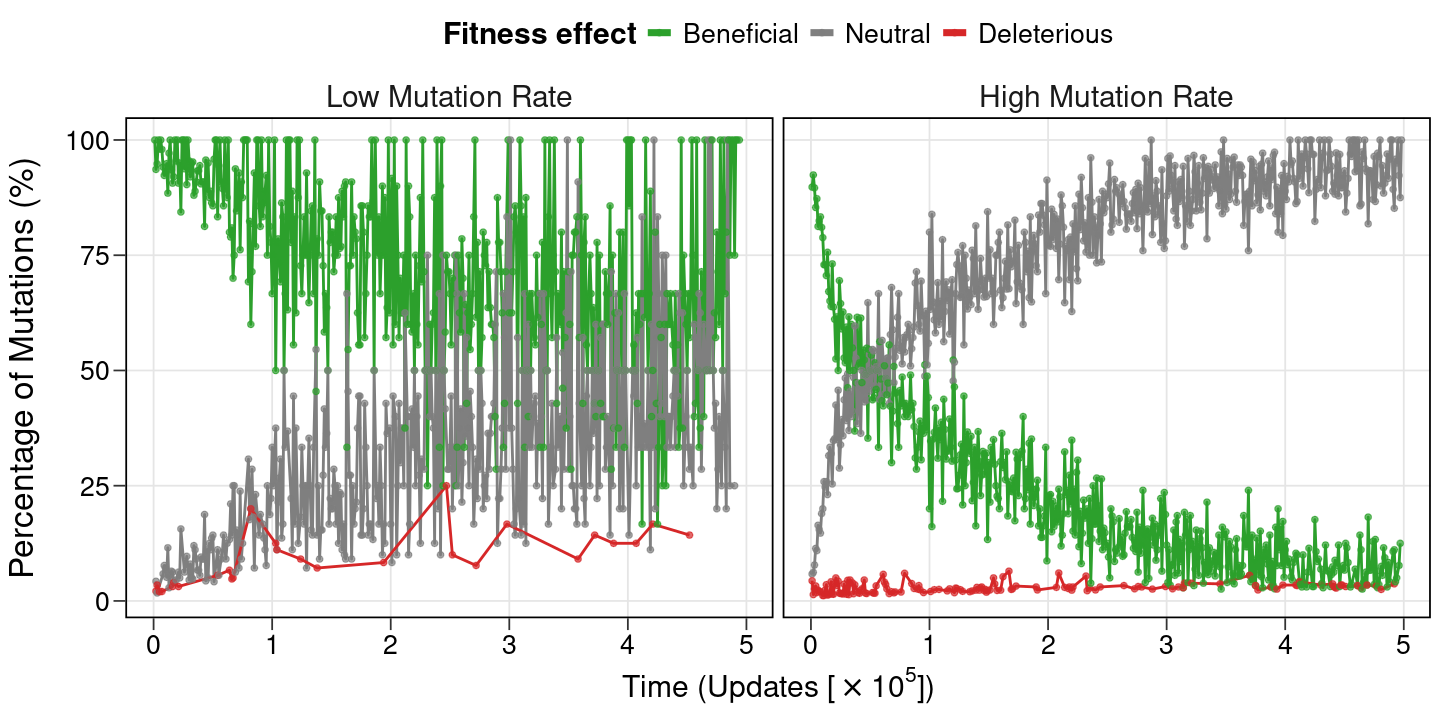

In [36]:
options(repr.plot.width = 12, repr.plot.height = 6)

global_distribution = ggplot(db_fixed_per100_NOT %>%
       mutate(
            mut_rate = factor(mut_rate, 
                              levels = c(0.001, 0.01), 
                              labels = c("Low Mutation Rate", "High Mutation Rate"))), 
       aes(x = update_bin, y = percentage, color = effect_type)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5, alpha = 0.7) +
  
  # Stratify by mutation rate
  facet_wrap(~ mut_rate) +
  scale_x_continuous(labels = function(x) x / 100000) +
                     
  # Color palette for fitness effects
  scale_color_manual(values = c(
    "Beneficial"  = "#2ca02c",  # Green
    "Neutral"     = "#7f7f7f",  # Gray
    "Deleterious" = "#d62728"   # Red
  )) +
  
labs(
    x = expression(paste("Time (Updates [", "" %*% 10^5, "])")),    
    y     = "Percentage of Mutations (%)",
    color = "Fitness effect",
    fill  = "Fitness effect" 
  ) +
  guides(color = guide_legend(override.aes = list(linewidth = 2))) +
  theme_bw() +
  theme(
      strip.text = element_text(size = 18), 
      strip.background = element_blank(),
      
      axis.title.x = element_text(size = 18, margin = margin(t = 5), color = "black"),
      axis.title.y = element_text(size = 20, margin = margin(r = 15), color = "black"),
      
      axis.text.x = element_text(color = "black", size = 16),
      axis.text.y = element_text(color = "black", size = 16),
      axis.ticks = element_line(linewidth = 0.5),
      axis.ticks.length = unit(0.25, "cm"),
      
      panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
      panel.grid.major = element_line(color = "gray90", linetype = "solid"),
      panel.grid.minor = element_blank(),
      
      legend.position = "top",
      legend.title = element_text(size = 18, face = "bold"),
      legend.text = element_text(size = 16),
  )
global_distribution

### Statistical analysis Figure 3A: Beneficial mutations dominate the entire adaptive process at a low mutation rate

In [37]:
db_fixed_per100_NOT %>% head(3)
db_fixed_per100_NOT %>% tail(3)

mut_rate,update_bin,effect_type,n,percentage
<fct>,<dbl>,<fct>,<int>,<dbl>
0.001,1000,Beneficial,37,100.000000
0.001,2000,Beneficial,44,93.617021
0.001,2000,Neutral,2,4.255319


mut_rate,update_bin,effect_type,n,percentage
<fct>,<dbl>,<fct>,<int>,<dbl>
0.01,497000,Beneficial,1,12.5
0.01,497000,Neutral,7,87.5
0.01,498000,Neutral,5,100.0


In [38]:
db_fixed_per100_NOT <- db_fixed_per100_NOT %>% filter(mut_rate == "0.001") %>% complete(update_bin, effect_type, fill = list(percentage = 0))


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 95332, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



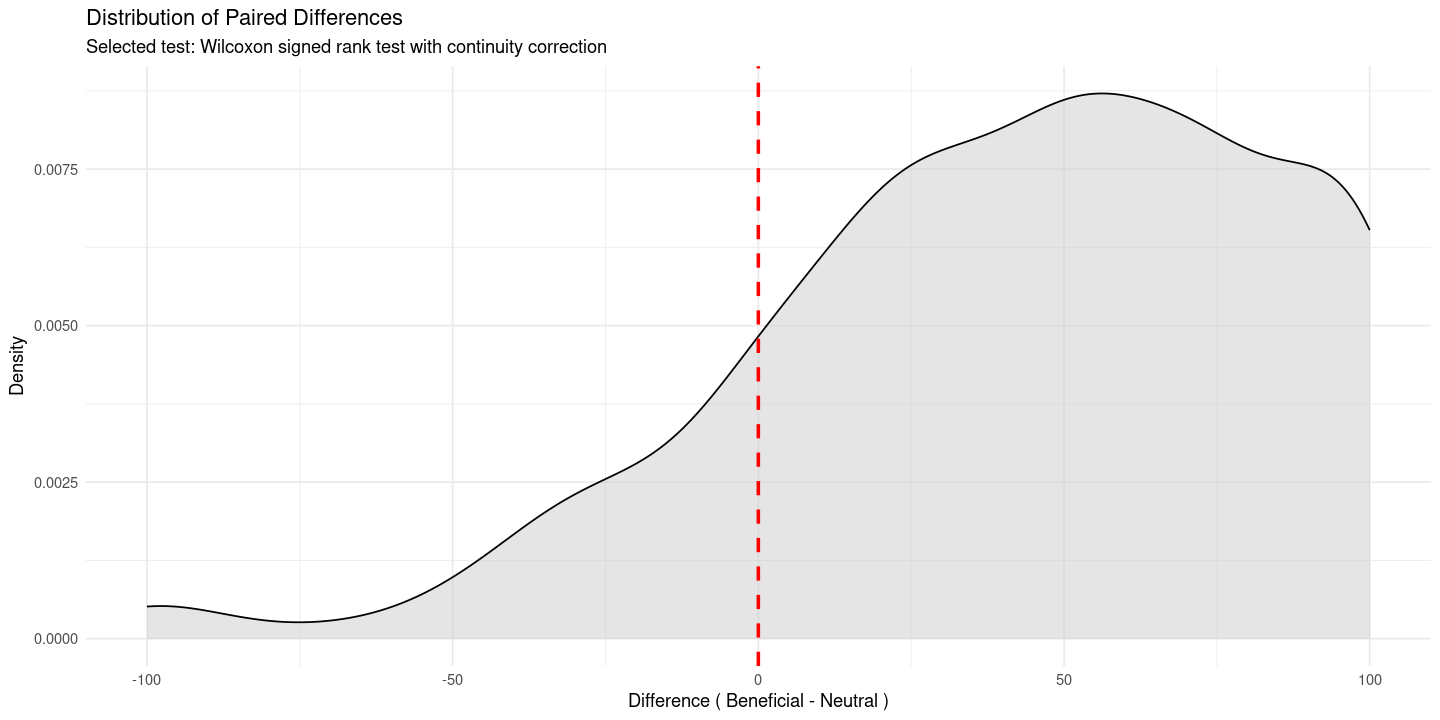

In [39]:
results_dominance <- perform_paired_analysis(
  data     = db_fixed_per100_NOT,
  rep_col  = "update_bin", 
  cond_col = "effect_type", 
  val_col  = "percentage",   
  group1   = "Beneficial",
  group2   = "Neutral"
)

### Figure 3B-E. Combined plot: results at the end of adaptation

#### Mutation effects dristribution at the end of experiment:

In [40]:
db_rel_fitness <- db_lineages_unique %>%
    filter(!is.na(mut_type)) %>%
    group_by(mut_rate, rep_id) %>%
    summarise(
        n_total_mut = n(),
        n_mut_beneficial = sum(relative_fitness > 1),
        n_mut_detrimental = sum(relative_fitness < 1),
        n_mut_neutral = sum(relative_fitness == 1), .groups = "drop")
db_rel_fitness %>% nrow
db_rel_fitness %>% head(3)
db_rel_fitness %>% tail(3)

[1] 400

mut_rate,rep_id,n_total_mut,n_mut_beneficial,n_mut_detrimental,n_mut_neutral
<dbl>,<dbl>,<int>,<int>,<int>,<int>
0.001,1,35,19,1,15
0.001,2,40,25,1,14
0.001,3,41,19,1,21


mut_rate,rep_id,n_total_mut,n_mut_beneficial,n_mut_detrimental,n_mut_neutral
<dbl>,<dbl>,<int>,<int>,<int>,<int>
0.01,198,265,22,5,238
0.01,199,231,26,8,197
0.01,200,235,12,4,219


In [41]:
db_rel_fitness_long <- db_rel_fitness %>%
    pivot_longer(
        cols = c(n_mut_beneficial, n_mut_detrimental, n_mut_neutral),
        names_to = "effect_mut",
        names_prefix = "n_mut_",
        values_to = "n_mut") %>%
    mutate(p_effect_mut = n_mut/n_total_mut)
db_rel_fitness_long %>% nrow
db_rel_fitness_long %>% head(3)
db_rel_fitness_long %>% tail(3)

[1] 1200

mut_rate,rep_id,n_total_mut,effect_mut,n_mut,p_effect_mut
<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>
0.001,1,35,beneficial,19,0.54285714
0.001,1,35,detrimental,1,0.02857143
0.001,1,35,neutral,15,0.42857143


mut_rate,rep_id,n_total_mut,effect_mut,n_mut,p_effect_mut
<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>
0.01,200,235,beneficial,12,0.05106383
0.01,200,235,detrimental,4,0.01702128
0.01,200,235,neutral,219,0.93191489


#### Pairwise genome distance at the end of adaptation:

In [25]:
LEVENSHTEIN_BIN <- "levenshtein/./levenshtein"
 
run_levenshtein <- function(sequences) {
    seqs <- unique(sequences)
    if (length(seqs) < 2) {
        return(tibble(n=length(seqs), pairs=0L, mean=NA_real_, variance=NA_real_))
    }
    tmp <- tempfile()
    write.table(seqs, tmp, quote=FALSE, row.names=FALSE, col.names=FALSE)
    out <- system(paste(LEVENSHTEIN_BIN, tmp, "2>&1"), intern=TRUE)
    file.remove(tmp)
    read.csv(text=tail(out, 1), header=FALSE,
             col.names=c("n", "pairs", "mean", "variance"))
}

In [26]:
# ==============================================================================
# 1. GET SEQUENCES AT THE PENULTIMATE update_sample PER REPLICATE
# ==============================================================================
seqs_final <- db_load_lineages %>%
    group_by(rep_id, mu) %>%
    mutate(penultimate = sort(unique(update), decreasing=TRUE)[2]) %>%
    filter(update == penultimate) %>%
    ungroup()
 
cat("Penultimate update_sample per group:\n")
seqs_final %>%
    distinct(rep_id, mu, update) %>%
    group_by(mu) %>%
    summarise(update = first(update), n_reps = n(), .groups="drop") %>%
    print()
 
cat("\nSequences per replicate:\n")
seqs_final %>%
    group_by(mu, rep_id) %>%
    summarise(n_seqs = n(), .groups="drop") %>%
    group_by(mu) %>%
    summarise(median_n = median(n_seqs),
              min_n    = min(n_seqs),
              max_n    = max(n_seqs), .groups="drop") %>%
    print()

Penultimate update_sample per group:
# A tibble: 2 × 3
     mu update n_reps
  <dbl>  <int>  <int>
1 0.001 499000    200
2 0.01  499000    200

Sequences per replicate:
# A tibble: 2 × 4
     mu median_n min_n max_n
  <dbl>    <dbl> <int> <int>
1 0.001       31    15    51
2 0.01       243   185   316


In [28]:
# ==============================================================================
# 2. LEVENSHTEIN WITHIN (rep_id x mut_rate)
# ==============================================================================
lev_final <- seqs_final %>%
    group_by(rep_id, mu) %>%
    group_modify(~ run_levenshtein(.x$sequence)) %>%
    ungroup() %>%
    filter(!is.na(mean)) 
 
cat("\nValid replicates:\n")
lev_final %>% count(mu) %>% print()
 
cat("\nSummary:\n")
lev_final %>%
    group_by(mu) %>%
    summarise(n=n(), median=median(mean), sd=sd(mean), .groups="drop") %>%
    print()


Valid replicates:
# A tibble: 2 × 2
     mu     n
  <dbl> <int>
1 0.001   200
2 0.01    200

Summary:
# A tibble: 2 × 4
     mu     n median      sd
  <dbl> <int>  <dbl>   <dbl>
1 0.001   200 0.0288 0.00917
2 0.01    200 0.141  0.0578 


### Combined plot. Figure 3B-E

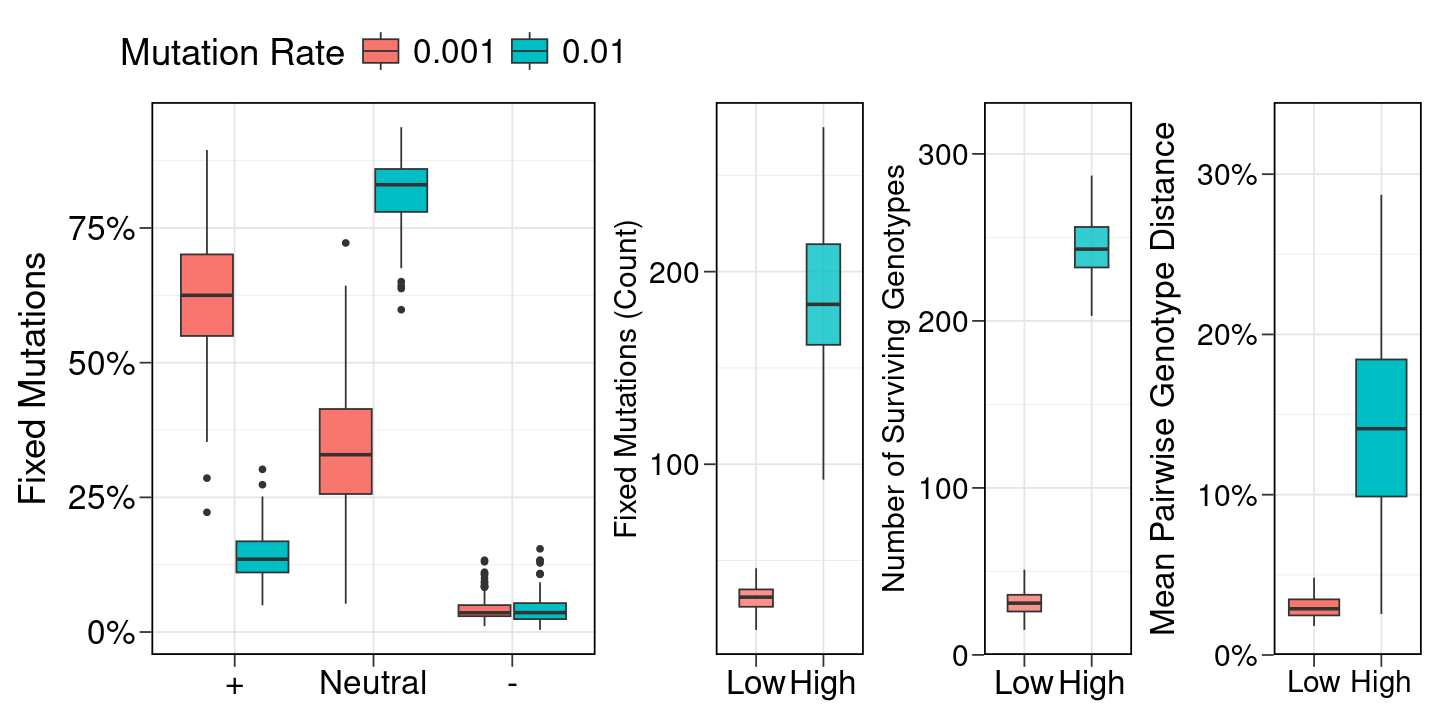

In [29]:
# Define shared color scale to ensure consistency across all panels
shared_fill <- scale_fill_manual(
  name   = "Mutation Rate",
  values = c("0.001" = "#F8766D", "0.01" = "#00BFC4"),
  labels = c("0.001" = "0.001", "0.01" = "0.01")
)
 
# Main panel: Proportion of fixed mutations by effect type
# (This plot holds the master legend for the final combined figure)
p_rel_fitness_NOT <- ggplot(
    db_rel_fitness_long %>%
        mutate(
          effect_mut = factor(effect_mut, levels = c("beneficial", "neutral", "detrimental")),
          mut_rate   = factor(mut_rate)
        ),
    aes(x = effect_mut, y = p_effect_mut, fill = mut_rate)
  ) +
  geom_boxplot(position = position_dodge(width = 0.8)) +
  shared_fill +
  scale_y_continuous(labels = percent) +
  scale_x_discrete(
    labels = c("beneficial" = "+", "neutral" = "Neutral", "detrimental" = "-")
  ) +
  labs(x = NULL, y = "Fixed Mutations", fill = "Mutation Rate") +
  theme_bw() +
  theme(
    plot.title        = element_blank(),
    axis.title.x      = element_blank(),
    axis.title.y      = element_text(size = 22, margin = margin(r = 10)),
    axis.text.x       = element_text(color = "black", size = 20),
    axis.text.y       = element_text(color = "black", size = 20),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major  = element_line(color = "gray90", linetype = "solid"),
    legend.position   = "top",
    legend.title      = element_text(size = 22),
    legend.text       = element_text(size = 20),
    legend.key.size   = unit(1.0, "cm")
  )
 
# Subpanel: Total count of fixed mutations prior to the final update
df_fixed_end <- db_lineages_unique %>%
  filter(mut_rate %in% c(0.001, 0.01)) %>%
  filter(update < 499000) %>%
  group_by(mut_rate, rep_id) %>%
  summarise(total_fixed = n(), .groups = "drop") %>%
  mutate(mut_rate = factor(mut_rate))
 
p_fixed_count <- ggplot(
    df_fixed_end,
    aes(x = mut_rate, y = total_fixed, fill = mut_rate)
  ) +
  geom_boxplot(alpha = 0.8, outlier.shape = NA, outlier.size = 1.5, width = 0.5) +
  shared_fill +
  scale_x_discrete(labels = c("0.001" = "Low", "0.01" = "High")) +
  labs(x = NULL, y = "Fixed Mutations (Count)") +
  theme_bw() +
  theme(
    plot.title        = element_blank(),
    axis.title.x      = element_blank(),
    axis.title.y      = element_text(size = 18, margin = margin(r = 5)),
    axis.text.x       = element_text(color = "black", size = 20),
    axis.text.y       = element_text(color = "black", size = 18),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major  = element_line(color = "gray90", linetype = "solid"),
    legend.position   = "none"
  )
 
# Subpanel: Number of surviving genotypes at the end of the experiment
db_alive <- db_load_lineages %>%
  filter(update == 499000) %>%
  group_by(mu, rep_id) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(mu = factor(mu))
 
p_living_genotypes <- ggplot(
    db_alive,
    aes(x = mu, y = n, fill = mu)
  ) +
  geom_boxplot(alpha = 0.8, outlier.shape = NA, outlier.size = 1.5, width = 0.5) +
  shared_fill +
  scale_x_discrete(labels = c("0.001" = "Low", "0.01" = "High")) +
  labs(x = NULL, y = "Number of Surviving Genotypes") +
  theme_bw() +
  theme(
    plot.title        = element_blank(),
    axis.title.x      = element_blank(),
    axis.title.y      = element_text(size = 18, margin = margin(r = 5)),
    axis.text.x       = element_text(color = "black", size = 20),
    axis.text.y       = element_text(color = "black", size = 18),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major  = element_line(color = "gray90", linetype = "solid"),
    legend.position   = "none"
  )
 
# Subpanel: Mean pairwise genotypic distance at the final update
p_lev_final <- ggplot(
    lev_final %>% mutate(mu = factor(mu)),
    aes(x = mu, y = mean, fill = mu)
  ) +
  geom_boxplot(position = position_dodge(width = 0.8), outlier.shape = NA) +
  shared_fill +
  scale_y_continuous(
    labels = scales::label_percent(),
    expand = expansion(mult = c(0.0, 0.15)) 
  ) +
  coord_cartesian(ylim = c(0,0.3)) +
  scale_x_discrete(labels = c("0.001" = "Low", "0.01" = "High")) +
  labs(x = NULL, y = "Mean Pairwise Genotype Distance") +
  theme_bw() +
  theme(
    plot.title        = element_blank(),
    axis.title.x      = element_blank(),
    axis.title.y      = element_text(size = 20, margin = margin(r = 10)),
    axis.text.x       = element_text(color = "black", size = 18),
    axis.text.y       = element_text(color = "black", size = 18),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major  = element_line(color = "gray90", linetype = "solid"),
    legend.position   = "none"
  )
 
# Assemble final figure layout
options(repr.plot.width = 12, repr.plot.height = 6)
 
combined_plot <- p_rel_fitness_NOT + p_fixed_count + p_living_genotypes + p_lev_final +
  plot_layout(widths = c(3, 1, 1, 1)) 
 
combined_plot

### Statistical analysis. Figure 3B-E

#### Figure 3B. Mutation effects dristribution at the end of experiment

In [52]:
# DESCRIPTIVE STATISTICS
stats_panelB <- db_rel_fitness_long %>%
  group_by(mut_rate, effect_mut) %>%
  summarise(
    median_val = median(p_effect_mut, na.rm = TRUE),
    q1_val     = quantile(p_effect_mut, 0.25, na.rm = TRUE),
    q3_val     = quantile(p_effect_mut, 0.75, na.rm = TRUE),
    .groups    = "drop"
  )

print("--- PANEL B: FIXED MUTATIONS BY EFFECT TYPE ---")
stats_panelB


[1] "--- PANEL B: FIXED MUTATIONS BY EFFECT TYPE ---"


mut_rate,effect_mut,median_val,q1_val,q3_val
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0.001,beneficial,0.62500000,0.54959677,0.70092593
0.001,detrimental,0.03571429,0.02941176,0.05000000
0.001,neutral,0.32916667,0.25626118,0.41400336
0.010,beneficial,0.13519052,0.11064196,0.16838879
0.010,detrimental,0.03607229,0.02406933,0.05369391
0.010,neutral,0.83024585,0.77982091,0.85945985


In [42]:
db_rel_fitness_long %>% head(3)

mut_rate,rep_id,n_total_mut,effect_mut,n_mut,p_effect_mut
<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>
0.001,1,35,beneficial,19,0.54285714
0.001,1,35,detrimental,1,0.02857143
0.001,1,35,neutral,15,0.42857143


In [43]:
interaction_model <- lm(p_effect_mut ~ as.factor(mut_rate) * as.factor(effect_mut), data = db_rel_fitness_long)

summary(interaction_model)

anova(interaction_model)


Call:
lm(formula = p_effect_mut ~ as.factor(mut_rate) * as.factor(effect_mut), 
    data = db_rel_fitness_long)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39743 -0.02598 -0.00404  0.03058  0.38438 

Coefficients:
                                                          Estimate Std. Error
(Intercept)                                               0.619656   0.005119
as.factor(mut_rate)0.01                                  -0.479139   0.007239
as.factor(effect_mut)detrimental                         -0.577151   0.007239
as.factor(effect_mut)neutral                             -0.281817   0.007239
as.factor(mut_rate)0.01:as.factor(effect_mut)detrimental  0.477749   0.010237
as.factor(mut_rate)0.01:as.factor(effect_mut)neutral      0.959667   0.010237
                                                         t value Pr(>|t|)    
(Intercept)                                               121.06   <2e-16 ***
as.factor(mut_rate)0.01                                   -66.19  

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
as.factor(mut_rate),1,1.972152e-31,1.972152e-31,3.763603e-29,1
as.factor(effect_mut),2,5.883343e+01,2.941672e+01,5.613808e+03,0
as.factor(mut_rate):as.factor(effect_mut),2,4.604829e+01,2.302415e+01,4.393867e+03,0
Residuals,1194,6.256637e+00,5.240065e-03,NA,NA


#### Figure 3C. Length of the adaptive walk

In [53]:
stats_panelC <- df_fixed_end %>%
  group_by(mut_rate) %>%
  summarise(
    median_val = median(total_fixed, na.rm = TRUE),
    q1_val     = quantile(total_fixed, 0.25, na.rm = TRUE),
    q3_val     = quantile(total_fixed, 0.75, na.rm = TRUE),
    .groups    = "drop"
  )

print("--- PANEL C: TOTAL FIXED MUTATIONS ---")
stats_panelC


[1] "--- PANEL C: TOTAL FIXED MUTATIONS ---"


mut_rate,median_val,q1_val,q3_val
<fct>,<dbl>,<dbl>,<dbl>
0.001,31,26,35.00
0.01,183,162,214.25


In [44]:
df_fixed_end %>% head(3)

mut_rate,rep_id,total_fixed
<fct>,<dbl>,<int>
0.001,1,35
0.001,2,40
0.001,3,40



--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.26877 

=> Differences FOLLOW a normal distribution (p > 0.05).
=> Running Paired T-Test (Parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Paired t-test

data:  vec_g1 and vec_g2
t = -63.141, df = 199, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -161.2691 -151.5009
sample estimates:
mean difference 
       -156.385 



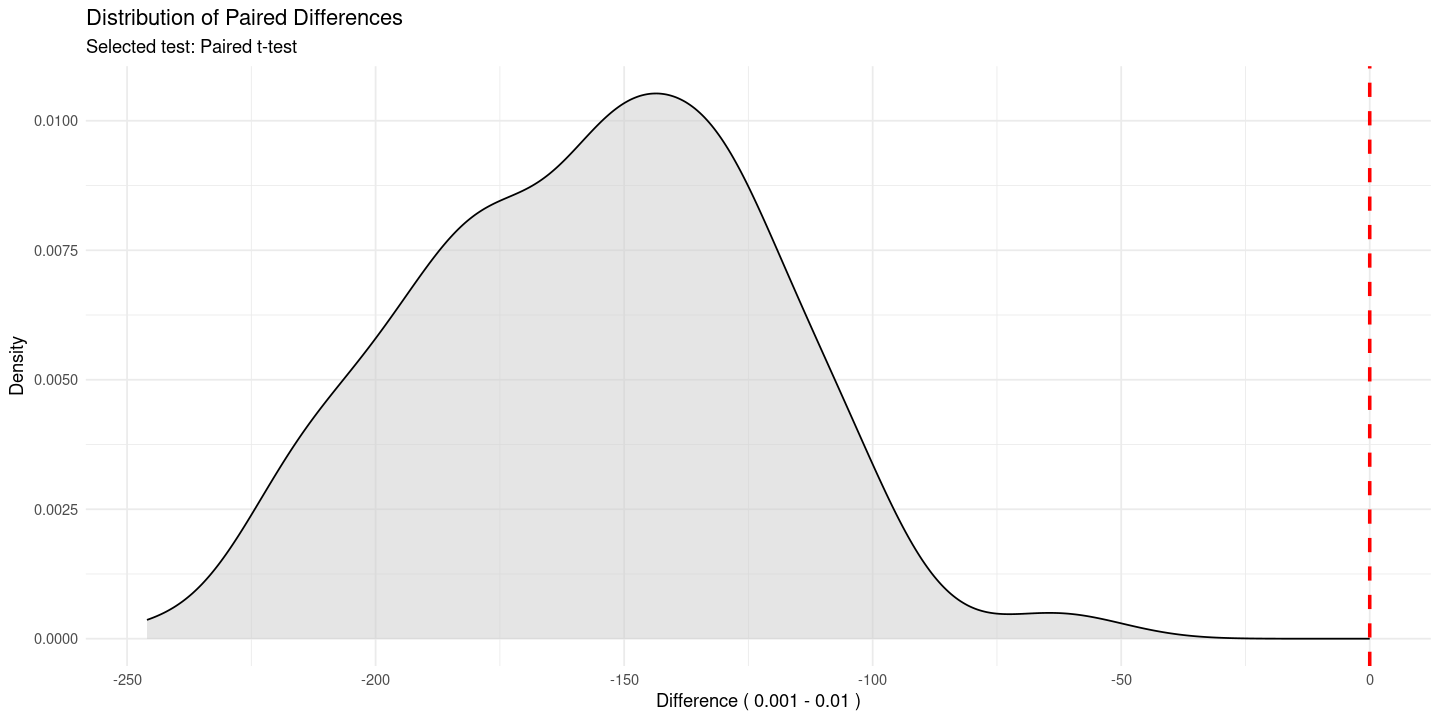

In [45]:
results_panelC <- perform_paired_analysis(
  data     = df_fixed_end,     
  rep_col  = "rep_id",         
  cond_col = "mut_rate",       
  val_col  = "total_fixed",   
  group1   = "0.001",
  group2   = "0.01"
)

#### Figure 3D. Genotypes alive at the end of experiments

In [54]:
stats_panelD <- db_alive %>%
  group_by(mu) %>%
  summarise(
    median_val = median(n, na.rm = TRUE),
    q1_val     = quantile(n, 0.25, na.rm = TRUE),
    q3_val     = quantile(n, 0.75, na.rm = TRUE),
    .groups    = "drop"
  )

print("--- PANEL D: SURVIVING GENOTYPES ---")
stats_panelD

[1] "--- PANEL D: SURVIVING GENOTYPES ---"


mu,median_val,q1_val,q3_val
<fct>,<dbl>,<dbl>,<dbl>
0.001,31,26,36.00
0.01,243,232,256.25


In [46]:
db_alive %>% head(3)

mu,rep_id,n
<fct>,<dbl>,<int>
0.001,1,34
0.001,2,31
0.001,3,36



--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.01084 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 0, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



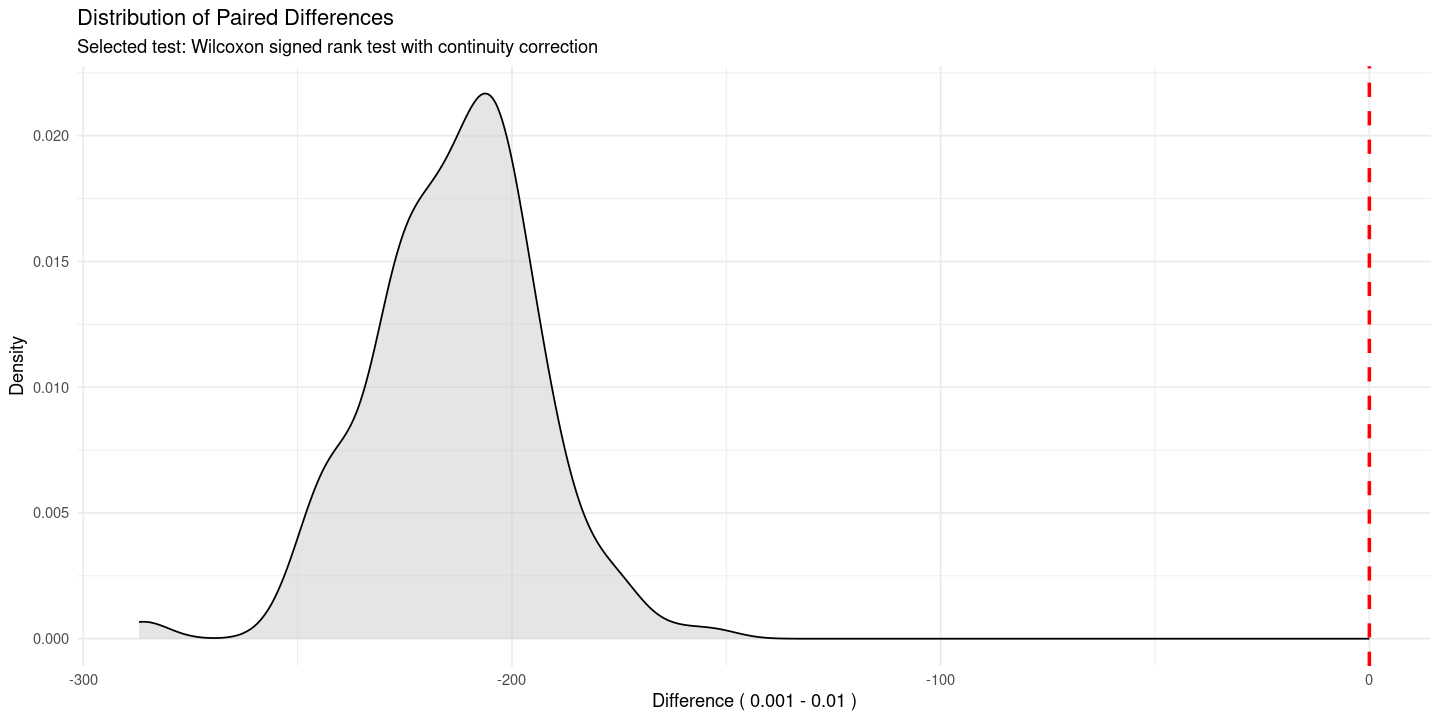

In [47]:
results_panelD <- perform_paired_analysis(
  data     = db_alive,         
  rep_col  = "rep_id",         
  cond_col = "mu",            
  val_col  = "n",              
  group1   = "0.001",
  group2   = "0.01"
)

#### Figure 3E. Mean pairwise Levenshtein distance 

In [55]:
stats_panelE <- lev_final %>%
  group_by(mu) %>%
  summarise(
    median_val = median(mean, na.rm = TRUE),
    q1_val     = quantile(mean, 0.25, na.rm = TRUE),
    q3_val     = quantile(mean, 0.75, na.rm = TRUE),
    .groups    = "drop"
  )

print("--- PANEL E: LEVENSHTEIN DISTANCE ---")
stats_panelE

[1] "--- PANEL E: LEVENSHTEIN DISTANCE ---"


mu,median_val,q1_val,q3_val
<dbl>,<dbl>,<dbl>,<dbl>
0.001,0.02884427,0.02472117,0.0347148
0.010,0.14119193,0.09888098,0.1843980


In [49]:
lev_final %>% head(3)

rep_id,mu,n,pairs,mean,variance
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,0.001,34,561,0.02555716,7.415381e-05
1,0.010,224,24976,0.15687355,5.516994e-03
2,0.001,31,465,0.03790484,3.077081e-04



--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.06644 

=> Differences FOLLOW a normal distribution (p > 0.05).
=> Running Paired T-Test (Parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Paired t-test

data:  vec_g1 and vec_g2
t = -27.483, df = 199, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1205415 -0.1044013
sample estimates:
mean difference 
     -0.1124714 



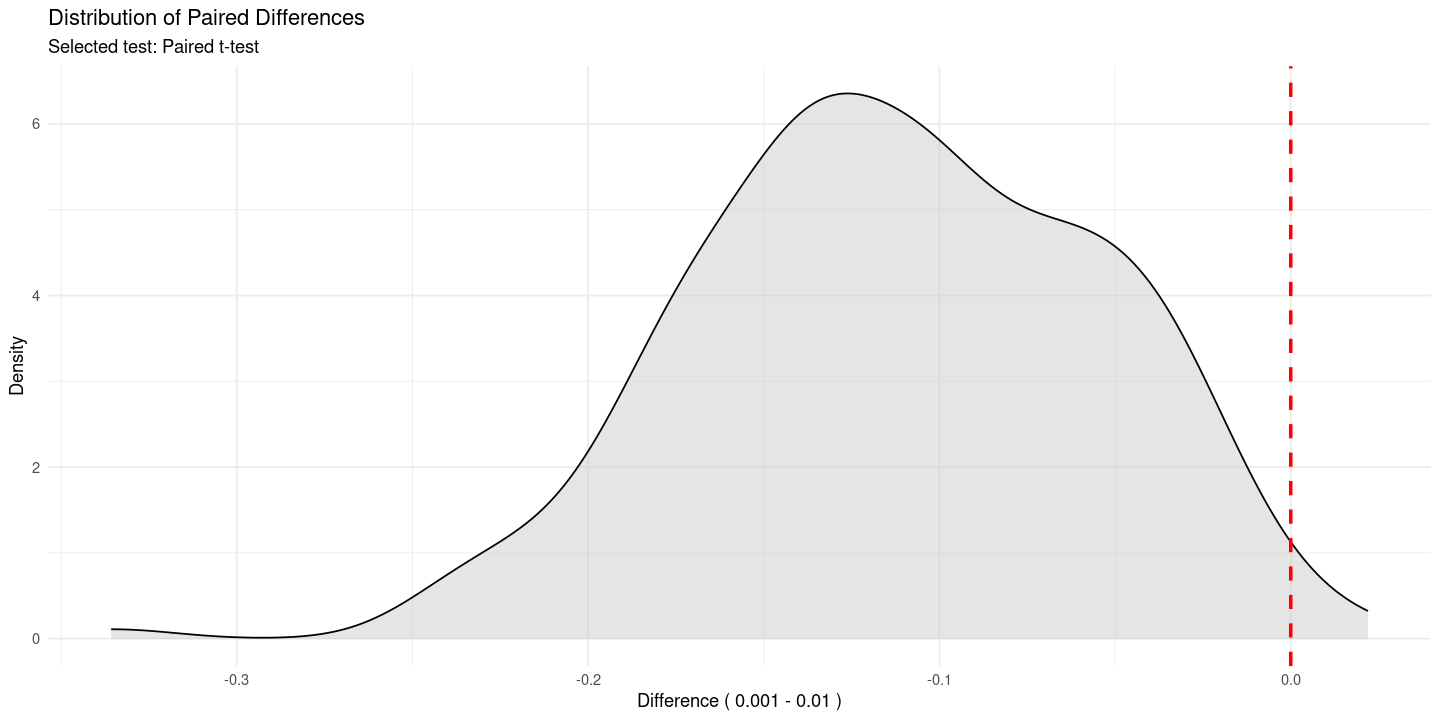

In [50]:
results_panelE <- perform_paired_analysis(
  data     = lev_final,        
  rep_col  = "rep_id",        
  cond_col = "mu",             
  val_col  = "mean",           
  group1   = "0.001",
  group2   = "0.01"
)

---

## Supplementary Figure 1. Mutational supply:

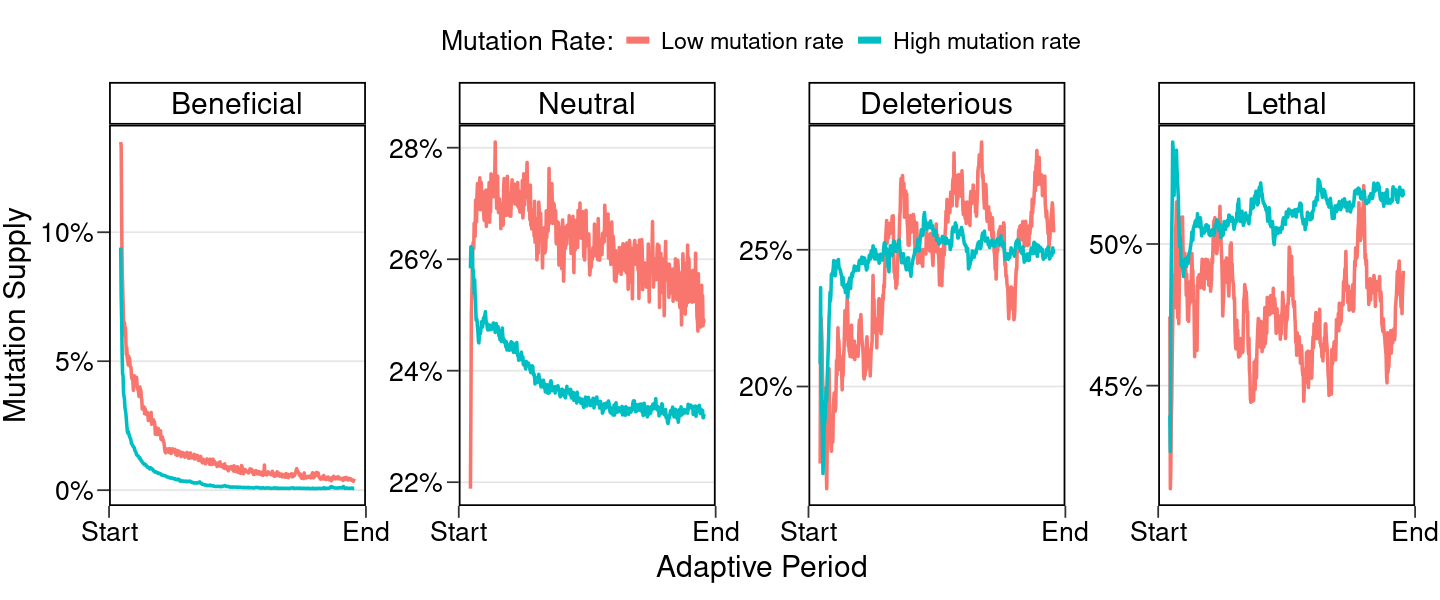

In [5]:
options(repr.plot.width = 12, repr.plot.height = 5)

supply_distribution_plot <- ggplot(
  db_available_summary %>%
    mutate(
      mut_rate = factor(mut_rate, 
                        levels = c("0.001", "0.01"), 
                        labels = c("Low mutation rate", "High mutation rate")),
      
      effect_type = factor(effect_type, 
                           levels = c("Beneficial", "Neutral", "Deleterious", "Lethal"),
                           labels = c("Beneficial", "Neutral", "Deleterious", "Lethal"))
    ), 
  
  aes(x = update_bin, y = percentage, color = mut_rate)
) +
  
  facet_wrap(~ effect_type, scales = "free_y", nrow = 1) +
  
  geom_line(linewidth = 1) +
  
  scale_x_continuous(
    breaks = function(x) c(min(x), max(x)),
    labels = c("Start", "End")
  ) +
  
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  
  labs(
    x = "Adaptive Period", 
    y = "Mutation Supply",
    color = "Mutation Rate:", 
    fill  = "Mutation Rate:" 
  ) +
  
  guides(color = guide_legend(override.aes = list(linewidth = 2))) +
  theme_bw() +
  
  theme(
    strip.text = element_text(size = 18, color = "black"), 
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    panel.spacing = unit(1, "lines"), 
      
    axis.title.x = element_text(size = 18, margin = margin(t = 5), color = "black"),
    axis.title.y = element_text(size = 18, margin = margin(r = 5), color = "black"),
  
    axis.text.x = element_text(color = "black", size = 16), 
    axis.text.y = element_text(color = "black", size = 16),
    axis.ticks = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
      
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major = element_line(color = "gray90", linetype = "solid"),
    panel.grid.minor = element_blank(),
      
    legend.position = "top",
    legend.title = element_text(size = 16),
    legend.text = element_text(size = 14),
    plot.margin = margin(t = 10, r = 15, b = 10, l = 2)
  )

supply_distribution_plot

### Statistical analysis. The lethal mutational supply steadily increases over time at a high mutation rate

In [7]:
df_high_lethal <- db_available_summary %>% 
  filter(mut_rate == 0.01, effect_type == "Lethal")

test_increase_lethal <- cor.test(
  x = df_high_lethal$update_bin, 
  y = df_high_lethal$percentage, 
  method = "spearman"
)

print(test_increase_lethal)


	Spearman's rank correlation rho

data:  df_high_lethal$update_bin and df_high_lethal$percentage
S = 7003346, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
     rho 
0.663838 



---

## Reproducibility Session Info

In [11]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.0 scales_1.3.0    lubridate_1.9.4 forcats_1.0.0  
 [5] stringr_1.5.1   dplyr_1.1.4     purrr_1.0.4     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1

---
---